# Regresión simple

In [20]:
import sys
import os

sys.path.append(os.path.abspath("../src"))

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from regresion import (
    descargar_datos_mercado,
    preparar_datos_regresion,
    estimar_regresion_simple
)

# 📊 Datos

In [21]:
datos = descargar_datos_mercado(
    start="2014-01-01",
    end="2024-12-31"
)

datos.head()

,SP500,VIX
2014-01-01,1782.589966,18.41
2014-02-01,1859.449951,14.00
2014-03-01,1872.339966,13.88
2014-04-01,1883.949951,13.41
2014-05-01,1923.569946,11.40


In [22]:
datos_reg = preparar_datos_regresion(datos)

datos_reg.head()

,SP500,VIX,ret_sp500,delta_vix
2014-02-01,1859.449951,14.00,0.043117,-4.41
2014-03-01,1872.339966,13.88,0.006932,-0.12
2014-04-01,1883.949951,13.41,0.006201,-0.47
2014-05-01,1923.569946,11.40,0.021030,-2.01
2014-06-01,1960.229980,11.57,0.019058,0.17


# 📈 Scatterplot

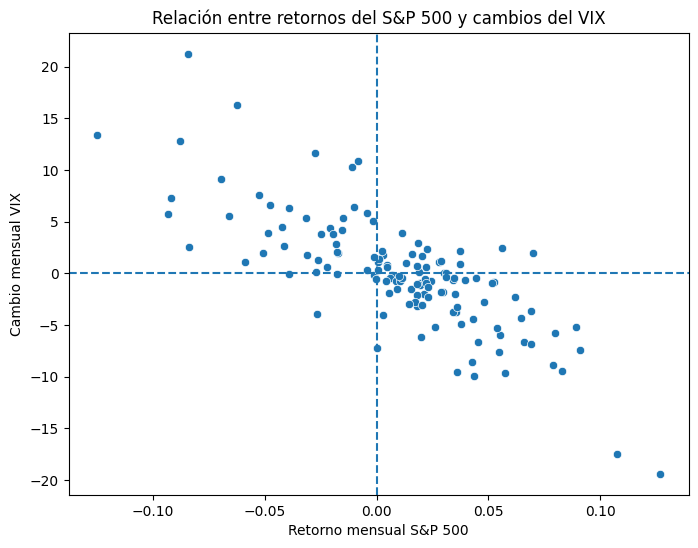

In [23]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=datos_reg,
    x="ret_sp500",
    y="delta_vix"
)

plt.axhline(0, linestyle="--")
plt.axvline(0, linestyle="--")

plt.title("Relación entre retornos del S&P 500 y cambios del VIX")
plt.xlabel("Retorno mensual S&P 500")
plt.ylabel("Cambio mensual VIX")

plt.show()

El gráfico muestra una relación negativa entre los retornos del S&P 500 y los cambios del VIX. Cuando el S&P 500 tiene retornos negativos, el VIX tiende a aumentar, reflejando mayor incertidumbre en el mercado. En cambio, cuando el mercado sube, el VIX suele mantenerse más bajo.

# 🔁 Regresión simple

In [24]:
modelo = estimar_regresion_simple(datos_reg)

print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:              delta_vix   R-squared:                       0.612
Model:                            OLS   Adj. R-squared:                  0.609
Method:                 Least Squares   F-statistic:                     203.6
Date:                Sun, 21 Jun 2026   Prob (F-statistic):           2.62e-28
Time:                        22:21:24   Log-Likelihood:                -348.93
No. Observations:                 131   AIC:                             701.9
Df Residuals:                     129   BIC:                             707.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.0232      0.314      3.257      0.0

Los resultados muestran que existe una relación inversa entre los retornos del S&P 500 y los cambios en el VIX. Cuando el S&P 500 sube, el VIX baja, cuando el mercado cae, el VIX tiende a aumentar. Esto indica que los inversionistas perciben más riesgo e incertidumbre cuando las acciones tienen un mal desempeño.
Además, el valor p es menor a 0,001, por lo que podemos concluir estadísticamente que existe relación entre ambas variables.
Financieramente, cuando el mercado está tranquilo y presenta buenos retornos, la volatilidad esperada disminuye. En cambio, cuando hay caídas o incertidumbre, el VIX aumenta.

# 📝 Prueba de hipótesis

H0: β = 0  
No existe relación significativa entre los retornos del S&P 500 y los cambios del VIX.

H1: β ≠ 0  
Sí existe relación significativa entre ambas variables.

# ⚙️ Ajuste del modelo de regresión

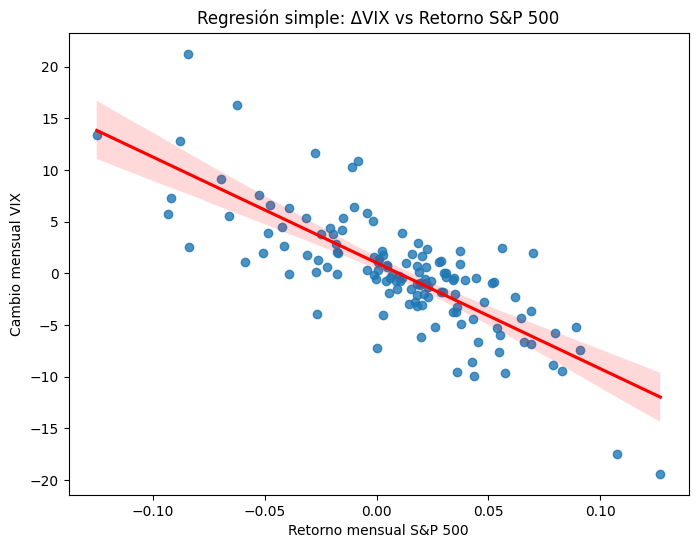

In [25]:
plt.figure(figsize=(8,6))

sns.regplot(
    data=datos_reg,
    x="ret_sp500",
    y="delta_vix",
    line_kws={"color": "red"}
)

plt.title("Regresión simple: ΔVIX vs Retorno S&P 500")
plt.xlabel("Retorno mensual S&P 500")
plt.ylabel("Cambio mensual VIX")

plt.show()

# 🤔 ¿Qué tanto explica el S&P 500?

El modelo presenta un R² de 0,612, lo que significa que aproximadamente el 61,2% de la variación mensual del VIX es explicada por los retornos del S&P 500. Esto indica una capacidad explicativa relativamente alta para una regresión simple.

# Regresión Múltiple

In [26]:
datos_multi = datos.copy()

datos_multi["ret_sp500"] = datos_multi["SP500"].pct_change()
datos_multi["abs_ret_sp500"] = abs(datos_multi["ret_sp500"])
datos_multi["ret_sp500_lag"] = datos_multi["ret_sp500"].shift(1)
datos_multi["cambio_volumen"] = datos_multi["Volume_SP500"].pct_change()
datos_multi["vix_lag"] = datos_multi["VIX"].shift(1)
datos_multi["delta_vix"] = datos_multi["VIX"].diff()

datos_multi = datos_multi.dropna()

datos_multi.head()

KeyError: 'Volume_SP500'

# ↔️ Correlación

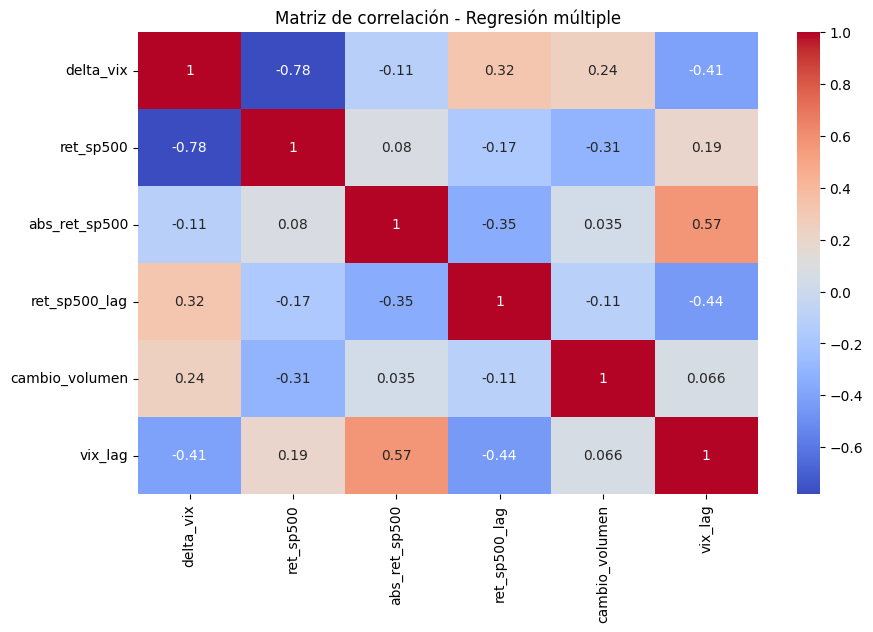

In [ ]:
variables = [
    "delta_vix",
    "ret_sp500",
    "abs_ret_sp500",
    "ret_sp500_lag",
    "cambio_volumen",
    "vix_lag"
]

corr_multi = datos_multi[variables].corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr_multi, annot=True, cmap="coolwarm")
plt.title("Matriz de correlación - Regresión múltiple")
plt.show()

explicación

# 🔁 Regresión multiple 

In [ ]:
y = datos_multi["delta_vix"]

X = datos_multi[
    [
        "ret_sp500",
        "abs_ret_sp500",
        "ret_sp500_lag",
        "cambio_volumen",
        "vix_lag"
    ]
]

X = sm.add_constant(X)

modelo_multi = sm.OLS(y, X).fit()

print(modelo_multi.summary())

                            OLS Regression Results                            
Dep. Variable:              delta_vix   R-squared:                       0.706
Model:                            OLS   Adj. R-squared:                  0.694
Method:                 Least Squares   F-statistic:                     59.59
Date:                Sun, 21 Jun 2026   Prob (F-statistic):           2.40e-31
Time:                        22:16:41   Log-Likelihood:                -328.41
No. Observations:                 130   AIC:                             668.8
Df Residuals:                     124   BIC:                             686.0
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              4.1386      0.877      4.

# 📝 Hipótesis

H0: βj = 0  
La variable no tiene efecto significativo sobre el cambio del VIX.

H1: βj ≠ 0  
La variable sí tiene efecto significativo sobre el cambio del VIX.

### Hipótesis del modelo

H0: β1 = β2 = β3 = β4 = β5 = 0  
El modelo completo no explica los cambios del VIX.

H1: Al menos un βj ≠ 0  
Al menos una variable ayuda a explicar los cambios del VIX.

# ↔️ Multicolinealidad

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = X.drop(columns="const")

vif = pd.DataFrame()
vif["Variable"] = X_vif.columns
vif["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

vif

,Variable,VIF
0,ret_sp500,1.250203
1,abs_ret_sp500,3.886337
2,ret_sp500_lag,1.075882
3,cambio_volumen,1.153508
4,vix_lag,4.114080
